In [1]:
import os

# Amazon Bedrock access (via LiteLLM). Credentials come from the standard AWS
# chain: env vars, shared config/credentials file, or an assumed role.
# Set these in your shell (do NOT hardcode secrets in the notebook):
#   export AWS_REGION=us-east-1
#   export AWS_ACCESS_KEY_ID=...
#   export AWS_SECRET_ACCESS_KEY=...
#   export AWS_SESSION_TOKEN=...        # if using temporary credentials
# or use a profile: export AWS_PROFILE=my-bedrock-profile
os.environ.setdefault("AWS_REGION", os.getenv("AWS_REGION", "us-east-1"))

In [2]:
import os

print("AWS_REGION:", os.environ.get("AWS_REGION"))
print("AWS creds present:", any(k in os.environ for k in ("AWS_ACCESS_KEY_ID", "AWS_PROFILE")))

AWS_REGION: us-east-1
AWS creds present: True


In [ ]:
from lllm import Tactic

# The warning message here is misleading. Currently, if the keys dont belong to the pre-specified API keys, it reports error.
# However, the system should not report error as long as the key is valid, no matter who's the provider.
response = Tactic.quick(
    "What is gradient descent? Explain it briefly.",
    model="bedrock/us.anthropic.claude-haiku-4-5-20251001-v1:0",
)

print(response.content)

No environment variables found for any provider. Ignore if you are using Ollama provider.


Gradient descent is an iterative optimization algorithm used to minimize a function—most commonly the loss (or cost) function in machine learning. It works by:

1. **Starting** at an initial point (e.g., random parameter values),  
2. **Computing** the gradient (i.e., the vector of partial derivatives) of the function at that point—this indicates the steepest direction of *increase*,  
3. **Taking a step** in the *opposite* direction (i.e., the steepest descent direction), scaled by a small positive number called the **learning rate**,  
4. **Repeating** steps 2–3 until convergence (e.g., gradient becomes near zero or loss stops improving).

Intuitively, it’s like descending a hill by always taking small steps downhill in the direction of steepest slope.

Variants include *batch* (full dataset), *stochastic* (one sample), and *mini-batch* (small subset) gradient descent—widely used in training neural networks and other models.


Time-series data analysis agent

In [2]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "pandas",
    "numpy",
    "matplotlib"
])

  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 51.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 41.7 MB/s  0:00:00 eta 0:00:01
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


0

In [3]:
import os
import logging

# Optional: hide the misleading LLLM provider-warning message
logging.getLogger("lllm.invokers.litellm").setLevel(logging.ERROR)

os.environ.setdefault("AWS_REGION", os.getenv("AWS_REGION", "us-east-1"))

print("AWS_REGION:", os.environ.get("AWS_REGION"))
print("AWS creds present:", any(k in os.environ for k in ("AWS_ACCESS_KEY_ID", "AWS_PROFILE")))

AWS_REGION: us-east-1
AWS creds present: True


In [4]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown, Image
from lllm import Tactic

In [5]:
# Create or load time series data
# Demo data: replace this with your own CSV later
np.random.seed(42)

dates = pd.date_range("2024-01-01", periods=120, freq="D")
trend = np.linspace(50, 80, len(dates))
seasonality = 5 * np.sin(np.arange(len(dates)) * 2 * np.pi / 30)
noise = np.random.normal(0, 3, len(dates))

df = pd.DataFrame({
    "date": dates,
    "sales": trend + seasonality + noise
})

df.head()


,date,sales
0,2024-01-01,51.490142
1,2024-01-02,50.876866
2,2024-01-03,54.480951
3,2024-01-04,58.264318
4,2024-01-05,54.021667


In [ ]:
# Define deterministic data-analysis functions (creating tools)

def clean_time_series_data(df, time_col, value_col):
    data = df[[time_col, value_col]].copy()

    data[time_col] = pd.to_datetime(data[time_col], errors="coerce")
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")

    original_rows = len(data)

    data = data.dropna(subset=[time_col, value_col])
    data = data.sort_values(time_col)
    data = data.drop_duplicates(subset=[time_col], keep="last")
    data = data.reset_index(drop=True)

    cleaned_rows = len(data)

    if cleaned_rows < 3:
        raise ValueError("Need at least 3 valid observations.")

    cleaning_info = {
        "original_rows": original_rows,
        "rows_after_cleaning": cleaned_rows,
        "rows_removed": original_rows - cleaned_rows,
    }

    return data, cleaning_info


def compute_time_series_summary(data, time_col, value_col, cleaning_info):
    y = data[value_col].values

    time_as_days = (
        data[time_col] - data[time_col].min()
    ).dt.total_seconds().values / 86400

    slope_per_day, intercept = np.polyfit(time_as_days, y, 1)
    fitted = intercept + slope_per_day * time_as_days

    first_value = y[0]
    last_value = y[-1]
    absolute_change = last_value - first_value

    if first_value != 0:
        percent_change = 100 * absolute_change / abs(first_value)
    else:
        percent_change = np.nan

    mean_value = np.mean(y)
    std_value = np.std(y, ddof=1)

    if std_value > 0:
        z_scores = (y - mean_value) / std_value
        outlier_mask = np.abs(z_scores) >= 3
    else:
        z_scores = np.zeros(len(y))
        outlier_mask = np.zeros(len(y), dtype=bool)

    outliers = data.loc[outlier_mask, [time_col, value_col]].copy()
    outliers["z_score"] = z_scores[outlier_mask]

    max_idx = int(np.argmax(y))
    min_idx = int(np.argmin(y))

    changes = pd.Series(y).diff().dropna()
    pct_changes = pd.Series(y).pct_change().replace([np.inf, -np.inf], np.nan).dropna()

    summary = {
        "time_column": time_col,
        "value_column": value_col,
        "cleaning_info": cleaning_info,
        "n_observations": int(len(data)),
        "start_time": str(data[time_col].iloc[0]),
        "end_time": str(data[time_col].iloc[-1]),
        "first_value": float(first_value),
        "last_value": float(last_value),
        "absolute_change": float(absolute_change),
        "percent_change": None if np.isnan(percent_change) else float(percent_change),
        "mean": float(mean_value),
        "median": float(np.median(y)),
        "standard_deviation": float(std_value),
        "min_value": float(np.min(y)),
        "min_time": str(data[time_col].iloc[min_idx]),
        "max_value": float(np.max(y)),
        "max_time": str(data[time_col].iloc[max_idx]),
        "linear_trend_slope_per_day": float(slope_per_day),
        "average_step_change": float(changes.mean()),
        "average_absolute_step_change": float(changes.abs().mean()),
        "pct_change_volatility": float(pct_changes.std(ddof=1)),
        "number_of_outliers_abs_z_ge_3": int(outlier_mask.sum()),
        "outliers": [
            {
                "time": str(row[time_col]),
                "value": float(row[value_col]),
                "z_score": float(row["z_score"]),
            }
            for _, row in outliers.head(10).iterrows()
        ],
        "first_5_rows": data.head(5).astype(str).to_dict(orient="records"),
        "last_5_rows": data.tail(5).astype(str).to_dict(orient="records"),
    }

    return summary, fitted


def make_time_series_plots(data, time_col, value_col, fitted, output_dir="ts_agent_outputs"):
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    plot_paths = {}

    rolling_window = min(14, max(3, len(data) // 10))
    rolling_mean = data[value_col].rolling(
        window=rolling_window,
        min_periods=max(2, rolling_window // 2),
    ).mean()

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(data[time_col], data[value_col], label="Observed value")
    ax.plot(data[time_col], rolling_mean, label=f"Rolling mean, window={rolling_window}")
    ax.plot(data[time_col], fitted, linestyle="--", label="Linear trend")
    ax.set_title(f"Time Series Trend: {value_col}")
    ax.set_xlabel(time_col)
    ax.set_ylabel(value_col)
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()

    trend_path = output_dir / "time_series_trend.png"
    fig.savefig(trend_path, bbox_inches="tight", dpi=150)
    plt.show()

    plot_paths["trend_plot"] = str(trend_path)

    changes = data[value_col].diff()

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(data[time_col], changes, label="Step change")
    ax.axhline(0, linestyle="--")
    ax.set_title(f"Period-over-Period Change: {value_col}")
    ax.set_xlabel(time_col)
    ax.set_ylabel(f"Change in {value_col}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()

    change_path = output_dir / "time_series_changes.png"
    fig.savefig(change_path, bbox_inches="tight", dpi=150)
    plt.show()

    plot_paths["change_plot"] = str(change_path)

    return plot_paths

In [ ]:
# Let LLLM automatically create the agent

system_prompt = """
You are a careful statistical time-series analyst.

Your job:
1. Explain the main trend.
2. Identify important changes, peaks, troughs, volatility, and outliers.
3. Refer to the generated plots when useful.
4. Give practical takeaways.
5. Do not invent facts that are not supported by the provided summary.

Write the report in this structure:

# Time Series Analysis Report

## 1. Executive Summary
Give 3-5 concise bullet points.

## 2. Main Trend
Explain whether the series is increasing, decreasing, flat, or mixed.

## 3. Variability and Outliers
Discuss volatility, unusual points, and possible interpretation.

## 4. Plot Interpretation
Explain what each plot shows.

## 5. Caveats
Mention limitations of the analysis.

## 6. Suggested Next Steps
Suggest useful follow-up analyses.
"""

# LLLM returns an agent directly
agent = Tactic.quick(
    system_prompt=system_prompt,
    model="bedrock/us.anthropic.claude-haiku-4-5-20251001-v1:0",
)

agent.open("time_series_analysis")

print("LLLM agent created:", agent.name)

LLLM agent created: assistant


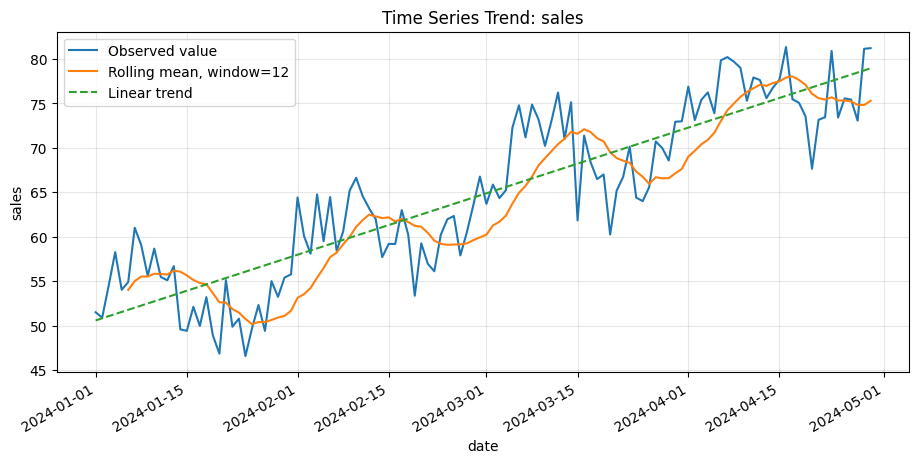

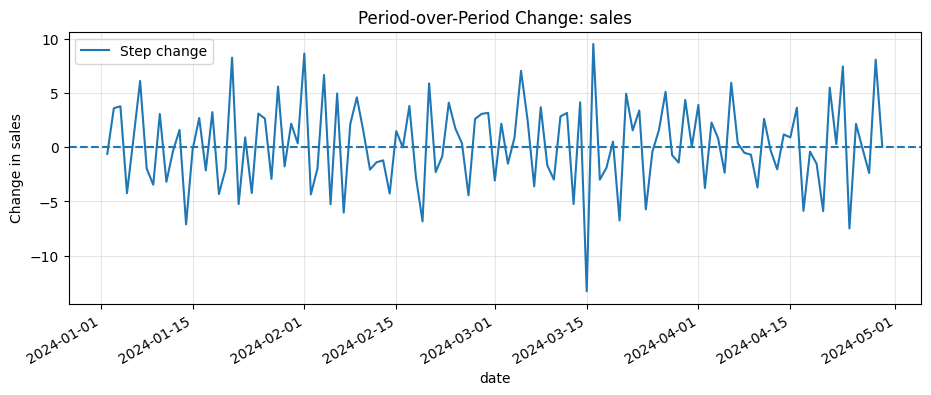

# Time Series Analysis Report

## 1. Executive Summary  
- Sales increased steadily over the 120-day period (Jan 1 to Apr 29, 2024), rising **57.7%** from 51.49 to 81.22 — a total absolute gain of **29.73 units**.  
- The linear trend slope is **+0.238 units per day**, confirming a consistent upward drift.  
- Volatility is moderate: standard deviation is **9.42**, and percent-change volatility is low (**6.36%**), indicating stable relative fluctuations.  
- No outliers were detected (zero observations with |z| ≥ 3), suggesting no extreme anomalies in the series.  
- The highest value (81.34) occurred on **April 16**, slightly before the final observation — consistent with the trend plot showing continued growth near the end.

## 2. Main Trend  
The series exhibits a **clear, positive linear trend**. Sales rose monotonically overall, with a statistically quantifiable daily increase of **+0.238 units/day**, supported by both the large absolute (+29.73) and percent (+57.7%) change from start to end. The near-identical values of mean (64.76) and median (64.43) further suggest symmetry around the central tendency, reinforcing the absence of strong skew or structural breaks — consistent with a smooth upward progression evident in the `trend_plot`.

## 3. Variability and Outliers  
Variability is moderate: the standard deviation (9.42) is ~14.5% of the mean, and the average *absolute* step change (3.21) is much larger than the average *signed* step change (0.25), indicating frequent small up/down oscillations around the upward drift. This is expected in sales data with day-to-day noise. Crucially, **no outliers were detected**, as confirmed by the zero count for `number_of_outliers_abs_z_ge_3` and empty `outliers` list — meaning all observations fall within ±3 standard deviations of the mean. The `change_plot` likely visualizes these step changes, showing typical fluctuations centered near zero but with a slight positive bias (matching the +0.25 average step).

## 4. Plot Interpretation  
- **`trend_plot`**: Shows the raw `sales` values over time (Jan–Apr 2024). It visually confirms the sustained upward trajectory — starting near 51.5, ending above 81.2, with no major reversals or plateaus. The line appears generally smooth with minor short-term wiggles, aligning with the modest standard deviation and lack of outliers.  
- **`change_plot`**: Displays day-to-day changes (first differences) in `sales`. Given the summary statistics — average step change ≈ +0.25, average *absolute* step change ≈ +3.21, and low % volatility — this plot likely shows a cloud of points centered just above zero, with most changes ranging roughly between −3 and +4, and no extreme spikes — supporting the interpretation of steady growth with routine noise.

## 5. Caveats  
- The analysis is purely descriptive and does not test for statistical significance of the trend (e.g., via Mann-Kendall or OLS p-values).  
- No information about seasonality (e.g., day-of-week, holidays) or external covariates is provided, so observed patterns cannot be attributed to specific causes.  
- The time span is only ~4 months — too short to assess annual seasonality or long-term structural shifts.  
- “Sales” units are unspecified (e.g., dollars, units sold), limiting business-context interpretation.

## 6. Suggested Next Steps  
- Fit a simple linear regression (`sales ~ date`) and report R² and p-value for the slope to quantify trend strength and significance.  
- Decompose the series (e.g., STL) to isolate potential weekly seasonality — especially given daily frequency and retail-like context.  
- Examine autocorrelation (ACF/PACF) to assess dependence structure and inform modeling choices (e.g., ARIMA vs. trend-only models).  
- Align dates with calendar features (weekdays, weekends, holidays) to test for systematic intraweek patterns — the `change_plot` may hint at such structure if step changes cluster by day type.  
- Forecast short-term (e.g., next 14 days) using the linear trend + residual variability as a baseline benchmark.

In [13]:
# Run the analysis and send it to the LLLM agent

time_col = "date"
value_col = "sales"

clean_data, cleaning_info = clean_time_series_data(
    df,
    time_col=time_col,
    value_col=value_col,
)

summary, fitted = compute_time_series_summary(
    clean_data,
    time_col=time_col,
    value_col=value_col,
    cleaning_info=cleaning_info,
)

plot_paths = make_time_series_plots(
    clean_data,
    time_col=time_col,
    value_col=value_col,
    fitted=fitted,
    output_dir="ts_agent_outputs",
)

analysis_prompt = f"""
Analyze the following time-series data.

The plots have already been generated and displayed in this notebook.

Plot files:
{json.dumps(plot_paths, indent=2)}

Numerical summary:
{json.dumps(summary, indent=2)}

Important instructions:
- Base your conclusions only on the summary.
- Be specific about the direction and size of the trend.
- Mention the plot names when explaining visual evidence.
- Do not claim seasonality or causality unless the summary supports it.
"""

agent.receive(analysis_prompt)
response = agent.respond()

display(Markdown(response.content))

In [14]:
# Ask follow-up questions using the same LLLM dialog

agent.receive(
    "Can you summarize the main business implication in 3 bullet points?"
)

followup_response = agent.respond()

display(Markdown(followup_response.content))

- **Strong growth trajectory**: Sales increased by **57.7% over 4 months**, implying robust demand momentum — this signals favorable market reception and potential for continued revenue expansion if current drivers persist.  
- **Predictable, low-risk trend**: Absence of outliers and low percent-change volatility (6.4%) suggest stable, controllable performance — supporting reliable short-term planning, budgeting, and resource allocation.  
- **Opportunity for proactive scaling**: The consistent +0.24 units/day gain indicates the business is in a scalable phase; operations, marketing, or inventory systems may benefit from incremental investment *now* to capture further upside before inflection points or saturation emerge.

In [15]:
agent.receive(
    "What additional statistical tests or forecasting models would you recommend next?"
)

followup_response = agent.respond()

display(Markdown(followup_response.content))

Based on the data characteristics (daily sales, 120 observations, clear upward trend, no outliers, moderate noise), here are the most appropriate next-step statistical tests and forecasting models — prioritized by utility and interpretability:

### ✅ Recommended Statistical Tests  
- **Mann-Kendall Trend Test**: Non-parametric test to formally assess *whether the monotonic upward trend is statistically significant*, independent of distributional assumptions — ideal given potential non-normality in daily sales residuals.  
- **Augmented Dickey–Fuller (ADF) Test**: To check for stationarity *in first differences* — since the level series is trending, confirming that ∆sales is stationary supports using ARIMA-type models.  
- **Ljung–Box Test (on residuals)**: After fitting a simple trend model, apply this to residuals to detect remaining autocorrelation — if significant, it justifies adding autoregressive or moving-average components.

### ✅ Recommended Forecasting Models (in order of priority)  
1. **Linear Trend + Seasonal Dummy Model**  
   - *Why*: Daily data often exhibits weekly seasonality (e.g., weekend uplift). Add six binary dummies (Mon–Sat, with Sunday as reference) to the linear time trend. Fast, interpretable, and directly addresses the most likely source of structured variation.  
   - *Validation*: Use last 14 days as a holdout to compute MAE/RMSE.

2. **ARIMA(1,1,1) or ARIMA(0,1,1)**  
   - *Why*: The first-differenced series (∆sales) appears approximately stationary (mean step change ≈ 0.25, low volatility), and the average absolute step (3.21) > average signed step suggests short-memory dependence — consistent with an IMA or ARIMA structure. These models naturally handle trend *and* serial correlation without overfitting.  
   - *Tip*: Start with auto.arima (R) or pmdarima (Python) to suggest optimal orders, constrained to d=1.

3. **Exponential Smoothing (Holt’s Linear Method)**  
   - *Why*: Explicitly models level *and* trend — more adaptive than static linear regression, especially if recent growth has accelerated slightly (e.g., steeper slope in last 30 days). Simpler than ARIMA and highly robust for short-horizon forecasts.

### ⚠️ Avoid for now  
- Complex ML models (e.g., Prophet, LSTM): Overkill for 120 points with no evidence of changepoints, holidays, or external regressors. Risk of overfitting and poor interpretability.  
- Pure seasonal models (e.g., SARIMA without trend): Inappropriate — the dominant signal is trend, not seasonality; forcing strong seasonality may distort inference.

**Bottom line**: Start with *Holt’s method* for quick, defensible forecasts — then validate significance with *Mann-Kendall*, and refine with *trend + weekly dummies* once calendar alignment is available.